In [ ]:
!sh data_multi30k.sh wmt16 wmt16 de en

# 初始化导入模块

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import sklearn
import pandas as pd
import sys
import time
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F

print(sys.version_info)
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)


sys.version_info(major=3, minor=12, micro=1, releaselevel='final', serial=0)
matplotlib 3.8.3
numpy 1.26.4
pandas 2.2.0
sklearn 1.7.0
torch 2.7.1+cpu
cpu


# MosesTokenizer预处理 subword-nmt分词

Total sentences: 29000
Min length: 2
Max length: 47
Mean length: 13.03
Median length: 12.0


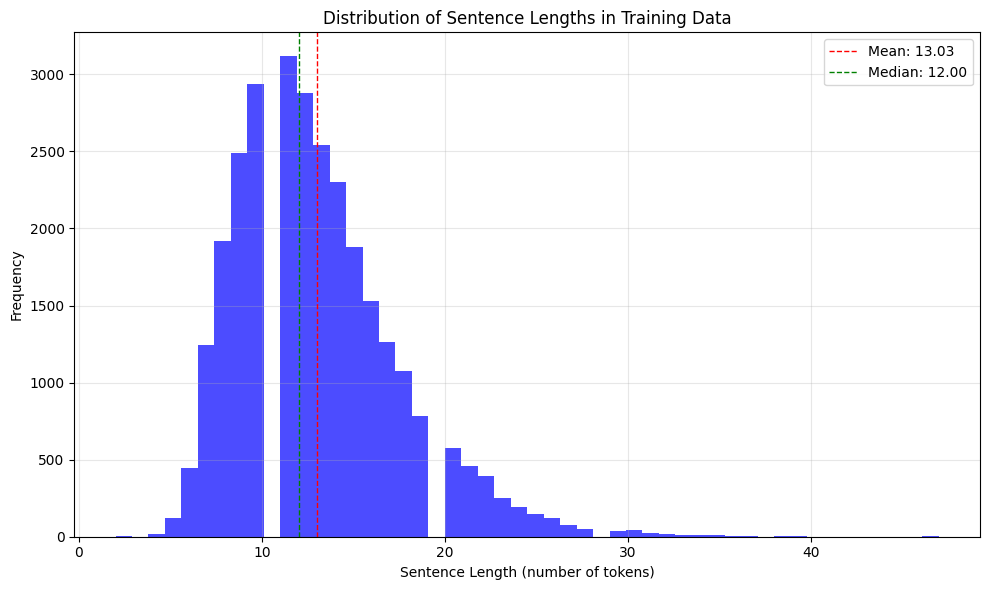

In [3]:
# Read the training source file and analyze sentence lengths
with open("wmt16/train_src.bpe", "r", encoding="utf8") as file:
    lines = file.readlines()

# Split each line and calculate lengths
lengths = [len(line.strip().split()) for line in lines]

# Create a histogram of sentence lengths
plt.figure(figsize=(10, 6))
plt.hist(lengths, bins=50, alpha=0.7, color='blue')
plt.xlabel('Sentence Length (number of tokens)')
plt.ylabel('Frequency')
plt.title('Distribution of Sentence Lengths in Training Data')
plt.grid(True, alpha=0.3)

# Add some statistics as text
plt.axvline(np.mean(lengths), color='r', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(lengths):.2f}')
plt.axvline(np.median(lengths), color='g', linestyle='dashed', linewidth=1, label=f'Median: {np.median(lengths):.2f}')
plt.legend()

# Display some statistics
print(f"Total sentences: {len(lengths)}")
print(f"Min length: {min(lengths)}")
print(f"Max length: {max(lengths)}")
print(f"Mean length: {np.mean(lengths):.2f}")
print(f"Median length: {np.median(lengths)}")

plt.tight_layout()
plt.show()


Total sentences: 29000
Min length: 16
Max length: 215
Mean length: 63.07
Median length: 60.0


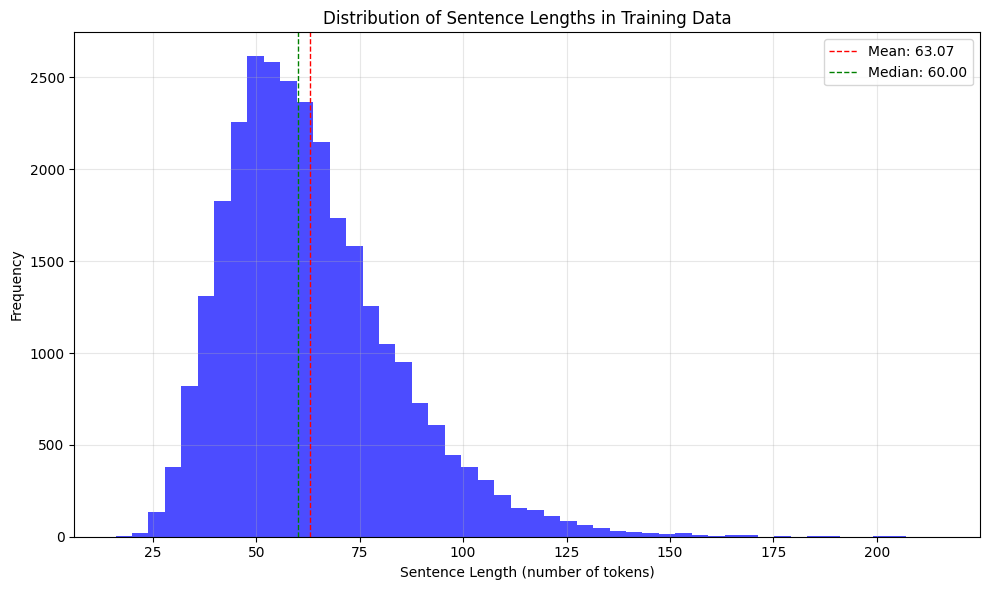

In [4]:
# Read the training source file and analyze sentence lengths
with open("wmt16/train_trg.bpe", "r", encoding="utf8") as file:
    lines = file.readlines()

# Split each line and calculate lengths
lengths = [len(line.strip()) for line in lines]

# Create a histogram of sentence lengths
plt.figure(figsize=(10, 6))
plt.hist(lengths, bins=50, alpha=0.7, color='blue')
plt.xlabel('Sentence Length (number of tokens)')
plt.ylabel('Frequency')
plt.title('Distribution of Sentence Lengths in Training Data')
plt.grid(True, alpha=0.3)

# Add some statistics as text
plt.axvline(np.mean(lengths), color='r', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(lengths):.2f}')
plt.axvline(np.median(lengths), color='g', linestyle='dashed', linewidth=1, label=f'Median: {np.median(lengths):.2f}')
plt.legend()

# Display some statistics
print(f"Total sentences: {len(lengths)}")
print(f"Min length: {min(lengths)}")
print(f"Max length: {max(lengths)}")
print(f"Mean length: {np.mean(lengths):.2f}")
print(f"Median length: {np.median(lengths)}")

plt.tight_layout()
plt.show()


# LangPairDataset

In [5]:
from pathlib import Path
from torch.utils.data import Dataset, DataLoader



class LangPairDataset(Dataset):

    def __init__(
        self, mode="train", max_length=273, overwrite_cache=False, data_dir="wmt16",
    ):
        self.data_dir = Path(data_dir) #封装为path对象
        cache_path = self.data_dir / ".cache" / f"de2en_{mode}_{max_length}.npy" # 缓存路径

        if overwrite_cache or not cache_path.exists(): #判断是否需要覆盖缓存，或者缓存文件不存在
            cache_path.parent.mkdir(parents=True, exist_ok=True) # 创建缓存目录

            with open(self.data_dir / f"{mode}_src.bpe", "r", encoding="utf8") as file:
                self.src = file.readlines() # 读取源语言文件所有行

            with open(self.data_dir / f"{mode}_trg.bpe", "r", encoding="utf8") as file:
                self.trg = file.readlines() # 读取目标语言文件所有行

            filtered_src = []
            filtered_trg = []
            # max length filter,超出最大长度的句子舍弃
            for src, trg in zip(self.src, self.trg):
                if len(src) <= max_length and len(trg) <= max_length: # 过滤长度超过最大长度的句子
                    filtered_src.append(src.strip()) # 去掉句子前后的空格
                    filtered_trg.append(trg.strip())
            filtered_src = np.array(filtered_src)
            filtered_trg = np.array(filtered_trg)
            np.save(
                cache_path,
                {"src": filtered_src, "trg": filtered_trg },
                allow_pickle=True,
            )#allow_pickle=True允许保存对象数组，将过滤后的数据保存为 NumPy 数组，存储在缓存文件中
            print(f"save cache to {cache_path}")

        else:
            cache_dict = np.load(cache_path, allow_pickle=True).item() #allow_pickle=True允许保存对象数组
            print(f"load {mode} dataset from {cache_path}")
            filtered_src = cache_dict["src"]
            filtered_trg = cache_dict["trg"]

        self.src = filtered_src
        self.trg = filtered_trg

    def __getitem__(self, index):
        return self.src[index], self.trg[index]

    def __len__(self):
        return len(self.src)


train_ds = LangPairDataset("train")
val_ds = LangPairDataset("val")

load train dataset from wmt16\.cache\de2en_train_273.npy
load val dataset from wmt16\.cache\de2en_val_273.npy


In [6]:
len(train_ds)

29000

# word2idx和idx2word词表创建

In [7]:
#载入词表，看下词表长度，词表就像英语字典,构建word2idx和idx2word
word2idx = {
    "[PAD]": 0,     # 填充 token
    "[BOS]": 1,     # begin of sentence
    "[UNK]": 2,     # 未知 token
    "[EOS]": 3,     # end of sentence
}
idx2word = {value: key for key, value in word2idx.items()}
index = len(idx2word)
threshold = 1  # 出现次数低于此的token舍弃

with open("wmt16/vocab", "r", encoding="utf8") as file:  # 打开词汇表文件进行读取，使用utf8编码
    for line in tqdm(file.readlines()):  # 使用tqdm显示进度条，遍历文件的每一行
        token, counts = line.strip().split()  # 去除每行两端的空白字符并按空格分割为token和出现次数
        if int(counts) >= threshold:  # 判断token的出现次数是否大于或等于阈值
            word2idx[token] = index  # 将token添加到word2idx字典，建立token到索引的映射
            idx2word[index] = token  # 将token添加到idx2word字典，建立索引到token的映射
            index += 1  # 索引值增加1，为下一个token准备

vocab_size = len(word2idx)  # 计算词表大小，即word2idx字典中的条目数量
print("vocab_size: {}".format(vocab_size))  # 打印词表大小


  0%|          | 0/18107 [00:00<?, ?it/s]

vocab_size: 18111


# Tokenizer

In [8]:
class Tokenizer:
    def __init__(self, word2idx, idx2word, max_length=128, pad_idx=0, bos_idx=1, eos_idx=3, unk_idx=2):
        self.word2idx = word2idx
        self.idx2word = idx2word
        self.max_length = max_length
        self.pad_idx = pad_idx
        self.bos_idx = bos_idx
        self.eos_idx = eos_idx
        self.unk_idx = unk_idx

    def encode(self, text_list, padding_first=False, add_bos=True, add_eos=True, return_mask=False):
        """如果padding_first == True，则padding加载前面，否则加载后面"""
        max_length = min(self.max_length, add_eos + add_bos + max([len(text) for text in text_list]))
        indices_list = []
        #text_list是句子列表，每个句子是一个单词列表,text_list是一个批次
        for text in text_list:
            indices = [self.word2idx.get(word, self.unk_idx) for word in text[:max_length - add_bos - add_eos]]
            if add_bos:#如果add_bos == True，则添加[BOS]
                indices = [self.bos_idx] + indices
            if add_eos:#如果add_eos == True，则添加[EOS]
                indices = indices + [self.eos_idx]
            if padding_first:#如果padding_first == True，则padding加载前面，否则加载后面
                indices = [self.pad_idx] * (max_length - len(indices)) + indices
            else:
                indices = indices + [self.pad_idx] * (max_length - len(indices))
            indices_list.append(indices)
        input_ids = torch.tensor(indices_list)
        masks = (input_ids == self.pad_idx).to(dtype=torch.int64) # 为了方便损失计算，这里的mask为0的地方需要计算，为1的地方不需要计算
        return input_ids if not return_mask else (input_ids, masks)


    def decode(self, indices_list, remove_bos=True, remove_eos=True, remove_pad=True, split=False):
        text_list = []
        for indices in indices_list:
            text = []
            for index in indices:
                word = self.idx2word.get(index, "[UNK]")
                if remove_bos and word == "[BOS]":
                    continue
                if remove_eos and word == "[EOS]":
                    break
                if remove_pad and word == "[PAD]":
                    break
                text.append(word)
            text_list.append(" ".join(text) if not split else text) #如果split == True，则返回一个单词列表，否则返回一个句子
        return text_list #返回一个句子列表


tokenizer = Tokenizer(word2idx=word2idx, idx2word=idx2word)


raw_text = ["hello world".split(), "a little boy playing gam@@ e@@ .".split(), "this is a test".split()]
indices = tokenizer.encode(raw_text, padding_first=False, add_bos=True, add_eos=True)
decode_text = tokenizer.decode(indices.tolist(), remove_bos=False, remove_eos=False, remove_pad=False)
print("raw text")
for raw in raw_text:
    print(raw)
print("indices")
for index in indices:
    print(index)
print("decode text")
for decode in decode_text:
    print(decode)

raw text
['hello', 'world']
['a', 'little', 'boy', 'playing', 'gam@@', 'e@@', '.']
['this', 'is', 'a', 'test']
indices
tensor([   1, 9458, 3522,    3,    0,    0,    0,    0,    0])
tensor([   1,    5,  105,   56,   63, 8664,  732,    4,    3])
tensor([   1,  385,   18,    5, 5699,    3,    0,    0,    0])
decode text
[BOS] hello world [EOS] [PAD] [PAD] [PAD] [PAD] [PAD]
[BOS] a little boy playing gam@@ e@@ . [EOS]
[BOS] this is a test [EOS] [PAD] [PAD] [PAD]


# SampleInfo,TokenBatchCreator,TransformerBatchSampler

In [9]:
class SampleInfo: #下面的info对象
    def __init__(self, i, lens):
        """
        记录文本对的序号和长度信息
        输入：
            - i (int): 文本对的序号。
            - lens (list): 文本对源语言和目标语言的长度
        """
        self.i = i
        # 加一是考虑填补在文本前后的特殊词元，lens[0]和lens[1]分别表示源语言和目标语言的长度
        # self.max_len = lens[0] + 1
        self.max_len = max(lens[0], lens[1]) + 1
        self.src_len = lens[0] + 1
        self.trg_len = lens[1] + 1

# 一个批量生成器，根据词元数目的限制来控制批量的大小。它会根据传入的样本信息，在不超过设定大小的情况下，逐步构建批量。
#就是箱子
class TokenBatchCreator:
    def __init__(self, batch_size):
        """
        参数:
        batch_size (int): 用于限制批量的大小。箱子大小 高*宽
        功能:
        初始化了一个空的批量列表 _batch。
        设定了初始的最大长度为 -1。
        存储了传入的 batch_size。
        """

        self.__batch = []  #这个就是之前的batch_size，就是第一个batch内有多少个样本
        self.max_len = -1  #箱子内最长的样本长度
        self._batch_size = batch_size # 限制批量的大小,假设是4096

    def append(self, info: SampleInfo):
        """
        参数:
        info (SampleInfo): 文本对的信息。
        功能:
        接收一个 SampleInfo 对象，并根据其最大长度信息更新当前批量的最大长度。
        如果将新的样本加入批量后超过了批量大小限制，它会返回已有的批量并将新的样本加入新的批量。
        否则，它会更新最大长度并将样本添加到当前批量中。
        """
        # 更新当前批量的最大长度
        cur_len = info.max_len # 当前样本的长度
        max_len = max(self.max_len, cur_len) # 每来一个样本，更新当前批次的最大长度
        # 如果新的样本加入批量后超过大小限制，则将已有的批量返回，新的样本加入新的批量
        if max_len * (len(self.__batch) + 1) > self._batch_size:
            self.__batch, result = [], self.__batch # 保存当前的batch，并返回,这里的result是之前的batch,_batch清空
            self.__batch.append(info) #箱子里的第一条样本，放入
            self.max_len = cur_len #因为是当前batch的第一个样本，所以它的长度就是当前长度
            return result
        else:
            self.max_len = max_len
            self.__batch.append(info) # 将样本添加到当前批量中
            return None

    @property
    def batch(self):
        return self.__batch

In [10]:
# 当一个自定义对象可以iter(自定义对象)时，会自动调用__iter__方法
from torch.utils.data import BatchSampler
import numpy as np


class TransformerBatchSampler(BatchSampler):
    def __init__(self,
                 dataset,
                 batch_size,
                 shuffle_batch=False,
                 clip_last_batch=False,
                 seed=0):
        """
        批量采样器
        输入:
            - dataset: 数据集
            - batch_size: 批量大小
            - shuffle_batch: 是否对生成的批量进行洗牌
            - clip_last_batch: 是否裁剪最后剩下的数据
            - seed: 随机数种子
        """
        self._dataset = dataset #数据集
        self._batch_size = batch_size #箱子大小
        self._shuffle_batch = shuffle_batch #是否打乱箱子
        self._clip_last_batch = clip_last_batch #是否裁剪最后剩下的数据
        self._seed = seed #下面3个是为了随机
        self._random = np.random
        self._random.seed(seed)

        self._sample_infos = [] #所有样本信息
        # 根据数据集中的每个样本，创建了对应的 SampleInfo 对象，包含了样本的索引和长度信息。
        for i, data in enumerate(self._dataset):
            lens = [len(data[0]), len(data[1])] #输入和输出的长度计算放到lens中
            self._sample_infos.append(SampleInfo(i, lens)) #每个样本信息

    def __iter__(self):
        """
        对数据集中的样本进行排序，排序规则是先按源语言长度排序，如果相同则按目标语言长度排序。
        使用 TokenBatchCreator 逐步组装批量数据，当满足批量大小时返回一个批量的样本信息。
        如果不裁剪最后一个批次的数据且存在剩余样本，则将这些样本组成最后一个批次。
        如果需要对批量进行洗牌，则对批次进行洗牌操作。
        通过迭代器，抛出每个批量的样本在数据集中的索引。
        """
        # 排序，如果源语言长度相同则按照目标语言的长度排列
        infos = sorted(self._sample_infos,
                       key=lambda x: (x.src_len, x.trg_len))
        # 把样本放入到箱子里，所有装箱后的箱子，每一个箱子都放入batch_infos
        batch_infos = [] #放箱子的列表，每个箱子都是一个batch
        batch_creator = TokenBatchCreator(self._batch_size) # 批量生成器,上面自定义的类
        for info in infos:
            batch = batch_creator.append(info)
            # 存够一个batch的样本信息后，会把这个batch返回，否则返回为None
            if batch is not None:
                batch_infos.append(batch)

        # 是否抛弃最后批量的文本对
        if not self._clip_last_batch and len(batch_creator.batch) != 0:
            batch_infos.append(batch_creator.batch) # 最后一个batch

        # 打乱batch，打乱的是箱子的顺序
        if self._shuffle_batch:
            self._random.shuffle(batch_infos)

        self.batch_number = len(batch_infos) #箱子数量
        # print(self.batch_number) #为了理解

        # 抛出一个箱子里所有样本的序号
        for batch in batch_infos:
            batch_indices = [info.i for info in batch] # 批量的样本在数据集中的索引，第一个batch[0,1,.....82]，第二个batch[83,84,85,86,87]
            yield batch_indices

    def __len__(self):
        """
        返回批量的数量
        """
        if hasattr(self, "batch_number"):
            return self.batch_number
        # 计算批量的数量,没有用到下面的情况，不用看
        batch_number = (len(self._dataset) +
                        self._batch_size) // self._batch_size
        return batch_number

In [11]:
sampler = TransformerBatchSampler(train_ds, batch_size=4096, shuffle_batch=True)

#为什么这里每个批量的样本对数目不一样呢？长度*batch_number>4096的时候，就会返回上一个batch，然后新的样本加入新的batch,具体要看TokenBatchCreator的44行

In [12]:
for idx, batch in enumerate(sampler):
    print("第{}批量的数据中含有文本对是：{}，数量为：{}".format(idx, batch, len(batch)))
    if idx >= 3:
        break

第0批量的数据中含有文本对是：[9107, 10753, 16443, 26511, 23197, 27561, 2289, 28887, 25321, 8029, 1921, 27881, 804, 12064, 4937, 10825, 20403, 21794, 1011, 11803, 2743, 11033, 21357, 6787, 27264, 24877, 28554, 28675, 3377, 720, 7005]，数量为：31
第1批量的数据中含有文本对是：[5251, 13027, 19187, 26133, 28219, 1603, 6469, 12633, 4423, 17585, 17839, 26877, 1837, 12925, 24569, 26581, 28167, 7385, 10885, 23498, 18862, 23462, 27539, 28513, 533, 22235, 2703, 2989, 20677, 24901, 25655, 1631, 2787, 6371, 27971, 3739, 4581, 16081, 19849]，数量为：39
第2批量的数据中含有文本对是：[26411, 10977, 22298, 2891, 15917, 8851, 9821, 24257, 12999, 10377, 18307, 2565, 26629, 28413, 12829, 3867, 10870, 4304, 17287, 16943, 20464, 21188, 24115, 14887, 17821, 20591, 2646, 6597, 9033, 25028, 27781, 16803]，数量为：32
第3批量的数据中含有文本对是：[14339, 20611, 21119, 21529, 21787, 23915, 24563, 24662, 27601, 2091, 2613, 2925, 3041, 3343, 4832, 6515, 13400, 16301, 16528, 18399, 21962, 27328, 28576, 3310, 4486, 5364, 7775, 8276, 10173, 10430, 11393, 11875, 13854, 15481, 19081, 19421,

# DataLoader

In [13]:
def collate_fct(batch, tokenizer):
    src_words = [pair[0].split() for pair in batch]
    trg_words = [pair[1].split() for pair in batch]

    # [BOS] src [EOS] [PAD]
    encoder_inputs, encoder_inputs_mask = tokenizer.encode(
        src_words, padding_first=False, add_bos=True, add_eos=True, return_mask=True
        )

    # [BOS] trg [PAD]
    decoder_inputs = tokenizer.encode(
        trg_words, padding_first=False, add_bos=True, add_eos=False, return_mask=False,
        )

    # trg [EOS] [PAD]
    decoder_labels, decoder_labels_mask = tokenizer.encode(
        trg_words, padding_first=False, add_bos=False, add_eos=True, return_mask=True
        )

    return {
        "encoder_inputs": encoder_inputs.to(device=device),
        "encoder_inputs_mask": encoder_inputs_mask.to(device=device),
        "decoder_inputs": decoder_inputs.to(device=device),
        "decoder_labels": decoder_labels.to(device=device),
        "decoder_labels_mask": decoder_labels_mask.to(device=device),
    }


In [14]:
from functools import partial # 固定collate_fct的tokenizer参数

#可以调大batch_size,来看最终的bleu，如果GPU内存不够，可以减小batch_size
sampler = TransformerBatchSampler(train_ds, batch_size=256, shuffle_batch=True)
# https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader
sample_dl = DataLoader(train_ds, batch_sampler=sampler, collate_fn=partial(collate_fct, tokenizer=tokenizer)) #partial函数，固定collate_fct的tokenizer参数

for batch in sample_dl:#外层是拿每个batch
    for key, value in batch.items():#内层是拿每个batch里面是一个字典
        print(key)
        print(value)
    break

encoder_inputs
tensor([[   1,   11,  591,   25,   12,    7,   17,  589,    9, 1757,  196,   27,
           67,  852, 2352,    4,    3],
        [   1,    7,   17,   13,  488,  157,    9,   24,    7, 1242,   73,   12,
          198, 1094,  308,    4,    3],
        [   1,   29,   58,   12,   11,   25,   97,   14,    8,  926,   12, 1145,
          625,    4,    3,    0,    0]])
encoder_inputs_mask
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1]])
decoder_inputs
tensor([[  1,   5,  38, 331,  91,  19,   5,  16, 462,  32, 950,  10,  66,   4,
           0],
        [  1,   5,  16,   6,   5,  45, 157, 109,  69, 113, 364, 265,   5, 757,
           4],
        [  1,  28, 684,  19,   5,  26,  62,  19, 222,   6,   5, 844,   4,   0,
           0]])
decoder_labels
tensor([[  5,  38, 331,  91,  19,   5,  16, 462,  32, 950,  10,  66,   4,   3,
           0],
        [ 

## 应用对数指数变换函数，公式计算

In [15]:
import torch
import math

def positional_encoding_weights(emb_size):
    # 计算底数和指数
    base = math.log(10000)
    exponent = -5 / emb_size
    
    # 应用指数函数
    # 将 base 转换为 tensor，因为 torch.exp 需要 tensor 类型的输入
    weight = torch.exp(torch.tensor(base)*exponent)
    
    return weight

emb_size = 10  # 举例，可以替换成你需要的大小
weight = positional_encoding_weights(emb_size)
print(weight)

tensor(0.0100)


# 定义模型
   - Transformer模型由Embedding、Transformer-Block组成
## - Embedding包括：
   - WordEmbedding
   - PositionEmbedding
## - 多头注意力
   Transformer-Block包括：
   - Self-Attention
   - Cross-Attention
   - MLP

## TransformerEmbedding

In [16]:
import torch
import torch.nn as nn
import math

class TransformerEmbedding(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.vocab_size = config["vocab_size"]
        self.hidden_size = config["d_model"]  # 词向量维度
        self.pad_idx = config["pad_idx"]  # 填充的索引
        self.max_length = config["max_length"] # 最大token长度
        dropout_rate = config["dropout"]  # 随机失活率
        
        # 词嵌入层
        self.word_embedding = nn.Embedding(
            num_embeddings=self.vocab_size,
            embedding_dim=self.hidden_size,
            padding_idx=self.pad_idx
        )
        
        # 位置编码层 - 不需要训练
        self.position_embedding = nn.Embedding(
            num_embeddings=self.max_length,
            embedding_dim=self.hidden_size
        )
        
        # 初始化位置编码，固定不训练
        self.register_buffer(
            "position_ids", torch.arange(self.max_length).expand((1, -1))
        )
        self.position_embedding.weight.requires_grad = False # 位置编码不需要训练
        self._init_position_encoding() # 初始化位置编码
        
        self.dropout = nn.Dropout(dropout_rate)
        
    def _init_position_encoding(self):
        """初始化位置编码权重"""
        position = torch.arange(self.max_length).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, self.hidden_size, 2) * (-math.log(10000.0) / self.hidden_size))
        
        position_encoding = torch.zeros(self.max_length, self.hidden_size)
        position_encoding[:, 0::2] = torch.sin(position * div_term)
        position_encoding[:, 1::2] = torch.cos(position * div_term)
        
        self.position_embedding.weight.data.copy_(position_encoding)
    
    def forward(self, x):
        seq_length = x.size(1)
        
        # 词嵌入
        word_embeddings = self.word_embedding(x)
        
        # 位置编码
        position_ids = self.position_ids[:, :seq_length]
        position_embeddings = self.position_embedding(position_ids)
        
        # 词嵌入 + 位置编码
        embeddings = word_embeddings + position_embeddings
        
        # 应用dropout
        embeddings = self.dropout(embeddings)
        
        return embeddings
# %% cell 23 code

# 初始化TransformerEmbedding并进行前向计算
config = {
    'vocab_size': 30000,
    'd_model': 128,
    'max_length': 64,
    'pad_idx': 0,
    'dropout': 0.1,
}


embedding_model = TransformerEmbedding(config=config)
# 创建模型实例

# 创建一个示例输入 (batch_size=2, seq_length=10)
sample_input = torch.randint(0, config['vocab_size'], (2, 10))
print(f"输入形状: {sample_input.shape}")

# 前向计算
output = embedding_model(sample_input)
print(f"输出形状: {output.shape}")


输入形状: torch.Size([2, 10])
输出形状: torch.Size([2, 10, 128])


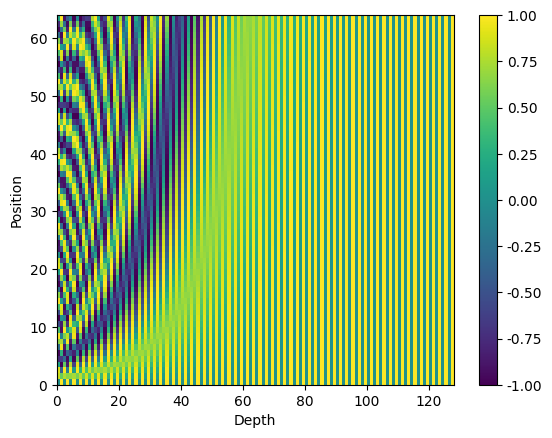

In [17]:
def plot_position_embedding(position_embedding):# 绘制位置编码
    plt.pcolormesh(position_embedding) # 绘制位置编码矩阵
    plt.xlabel('Depth')
    plt.ylabel('Position')
    plt.colorbar() # 颜色条，-1到1的颜色范围
    plt.show()

# 创建TransformerEmbedding实例并绘制位置编码
config = {
    'vocab_size': 30000,
    'd_model': 128,
    'max_length': 64,
    'pad_idx':0,
    'dropout':0.1,
}
embedding_model = TransformerEmbedding(config=config)
position_embedding_data = embedding_model.position_embedding.weight.data
plot_position_embedding(position_embedding_data)

## MultiHeadAttention-多头缩放点积注意力

In [ ]:
# 定义缩放点积注意力类，并实现split_heads、merge_heads、scaled_dot_product_attention等方法
# Define the scaled dot-product attention class, including split_heads, merge_heads, and scaled_dot_product_attention

from dataclasses import dataclass

Tensor = torch.Tensor

@dataclass
class AttentionOutput:
    hidden_states: Tensor  # 输出的隐藏状态
    attn_scores: Tensor    # 注意力分数

class ScaledDotProductAttention(nn.Module):
    def __init__(self, config):
        """
        使用config字典初始化多头注意力层
        config参数示例:
        {
            'd_model': 128,
            'num_heads': 8,
            
        }
        """
        super().__init__()
        self.hidden_size = config["d_model"]  # 输入特征维度
        self.num_heads = config["num_heads"]  # 注意力头数
        self.head_dim = self.hidden_size // self.num_heads  # 每个头的维度
        assert self.hidden_size % self.num_heads == 0, "hidden_size must be divisible by num_heads"  # 检查能否整除

        # 定义线性变换
        self.q_linear = nn.Linear(self.hidden_size, self.hidden_size)
        self.k_linear = nn.Linear(self.hidden_size, self.hidden_size)
        self.v_linear = nn.Linear(self.hidden_size, self.hidden_size)
        self.out_linear = nn.Linear(self.hidden_size, self.hidden_size)
        

    def split_heads(self, x):
        # 将输入张量分割为多个头
        # x: (batch_size, seq_len, hidden_size)
        batch_size, seq_len, hidden_size = x.size() # 获取输入张量的形状
        x = x.view(batch_size, seq_len, self.num_heads, self.head_dim)
        x = x.permute(0, 2, 1, 3)  # (batch_size, num_heads, seq_len, head_dim)
        return x
        # 将输入张量分割为多个头
        # x: (batch_size, seq_len, hidden_size)
        # 返回: (batch_size, num_heads, seq_len, head_dim)

    def merge_heads(self, x):
        # 将多个头的张量合并回原始形状
        # x: (batch_size, num_heads, seq_len, head_dim)
        batch_size, num_heads, seq_len, head_dim = x.size()
        x = x.permute(0, 2, 1, 3).contiguous()  # (batch_size, seq_len, num_heads, head_dim)
        x = x.view(batch_size, seq_len, num_heads * head_dim)
        return x
        # 将多个头的张量合并回原始形状
        # x: (batch_size, num_heads, seq_len, head_dim)
        # 返回: (batch_size, seq_len, hidden_size)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        # 计算缩放点积注意力
        # Q, K, V: (batch_size, num_heads, seq_len, head_dim)
        # mask: (batch_size, 1, 1, seq_len) 或 (batch_size, 1, seq_len, seq_len)
        d_k = Q.size(-1)
        # 注意：torch.sqrt输入必须是float类型
        # Note: torch.sqrt input must be float
        scores = torch.matmul(Q, K.transpose(-2, -1)) / torch.sqrt(torch.tensor(float(d_k), device=Q.device))
        # 计算注意力分数
        # scores: (batch_size, num_heads, seq_len, seq_len) 四维张量
        print(f'mask.shape:{mask.shape}')
        if mask is not None:
            # mask应为bool或0/1，形状可广播到scores
            # mask should be bool or 0/1, shape broadcastable to scores
            # print(f'mask.shape:{mask.shape}')  # 可选调试
            scores = scores.masked_fill(mask == 0, float('-inf'))  # 掩码填充
        attn_weights = F.softmax(scores, dim=-1)  # softmax归一化,torch.nn.functional=F
        # attn_weights = self.dropout(attn_weights)
        output = torch.matmul(attn_weights, V)  # 加权求和
        return output, attn_weights
        # 返回注意力输出和权重

    def forward(self, query, key, value, mask=None):
        # 前向计算
        # query, key, value: (batch_size, seq_len, hidden_size)
        Q = self.q_linear(query)
        K = self.k_linear(key)
        V = self.v_linear(value)
        # 线性变换

        # 分头
        Q = self.split_heads(Q)
        K = self.split_heads(K)
        V = self.split_heads(V)
        # 分头

        # 计算缩放点积注意力,scaled_attention (batch_size, num_heads, seq_len_q, depth)
        # attention_weights (batch_size, num_heads, seq_len_q, seq_len_k)
        attn_output, attn_weights = self.scaled_dot_product_attention(Q, K, V, mask)
        
        # 合并头
        concat = self.merge_heads(attn_output)
        
        # 输出线性变换
        output = self.out_linear(concat) # (batch_size, seq_len_q, d_model)
        
        return AttentionOutput(hidden_states=output, attn_scores=attn_weights)
        # 返回AttentionOutput对象，包含隐藏状态output和注意力分数attn_weights

# 说明：
# 1. 该类现在通过config字典进行初始化，hidden_size属性替换了d_model，便于统一管理模型参数。
# 2. 其余实现与原始代码一致，保持PyTorch风格。
# 3. 这样可以方便地与其他模块共享config配置。
# 中文翻译：
# 1. 该类现在通过config字典进行初始化，hidden_size属性替换了d_model，便于统一管理模型参数。
# 2. 其余实现与原始代码一致，保持PyTorch风格。
# 3. 这样可以方便地与其他模块共享config配置。


In [51]:
# 创建配置字典
# Create the config dictionary for the ScaledDotProductAttention
hidden_size = 128  # 可以根据需要修改隐藏层维度
num_heads = 8      # 可以根据需要修改头数

config = {
    'd_model': hidden_size,
    'num_heads': num_heads
}

# 实例化缩放点积注意力类
# Instantiate the ScaledDotProductAttention class
attention = ScaledDotProductAttention(config)

# 构造模拟输入数据
# Construct dummy input data
batch_size = 2
seq_len = 4

# 随机生成query, key, value张量，K=V=kv
# Randomly generate query, key, value tensors
query = torch.randn(batch_size, seq_len, hidden_size)
key = value = torch.randn(batch_size, seq_len, hidden_size)
# value = torch.randn(batch_size, seq_len, hidden_size)

# 构造mask，这里假设所有位置都可见（全1），shape为(batch_size, seq_len)
# Construct mask, here we assume all positions are visible (all ones), shape is (batch_size, seq_len)
mask_2d = torch.ones(batch_size, seq_len)

# 将mask由二维reshape为四维，shape为(batch_size, num_heads, seq_len, seq_len)
# Reshape the mask from 2D to 4D, shape is (batch_size, num_heads, seq_len, seq_len)
# 这里假设mask用于自注意力，即每个序列的每个位置都可以看到所有位置
# Here we assume the mask is for self-attention, i.e., every position can see all positions
mask_4d = mask_2d.unsqueeze(1).unsqueeze(2)
# mask_2d: (batch_size, seq_len) -> (batch_size, 1, 1, seq_len) -> (batch_size, num_heads, seq_len, seq_len)

# 前向计算，获得输出，传入4维mask
# Forward pass to get the output, pass the 4D mask
output = attention(query, key, value, mask=mask_4d)

# 打印输出的隐藏状态和注意力分数的形状
# Print the shapes of the output hidden states and attention scores
print("Output hidden_states shape:", output.hidden_states.shape)  # (batch_size, seq_len, hidden_size)
print("Output attn_scores shape:", output.attn_scores.shape)      # (batch_size, num_heads, seq_len, seq_len)

# 中文注释：
# 1. 创建了一个配置字典config，包含'd_model'和'num_heads'，用于初始化注意力层。
# 2. 随机生成了query、key、value张量，模拟输入数据。
# 3. 构造了二维mask，并reshape为四维mask，适用于多头自注意力。
# 4. 实例化了ScaledDotProductAttention类，并进行了前向计算，最后打印输出的形状用于验证。


mask.shape:torch.Size([2, 1, 1, 4])
Output hidden_states shape: torch.Size([2, 4, 128])
Output attn_scores shape: torch.Size([2, 8, 4, 4])


## TransformerBlock

In [71]:
from dataclasses import dataclass
from typing import Optional
import torch
import torch.nn as nn

# 定义TransformerBlockOutput数据类，用于存储TransformerBlock的输出
# Define the TransformerBlockOutput dataclass to store the output of TransformerBlock
@dataclass
class TransformerBlockOutput:
    hidden_states: torch.Tensor
    self_attn_scores: torch.Tensor
    cross_attn_scores: Optional[torch.Tensor] = None

# 定义TransformerBlock类
# Define the TransformerBlock class
class TransformerBlock(nn.Module):
    def __init__(self, config,has_cross_attention=False):
        super().__init__()
        self.has_cross_attention = has_cross_attention
        d_model = config.get('d_model',64)
        d_ff = config.get('d_ff', d_model * 4)

        # 为不同组件创建独立的dropout层
        # Create independent dropout layers for different components
        self.self_attn_dropout = nn.Dropout(config.get('dropout', 0.1))   # 自注意力层的dropout
        self.cross_attn_dropout = nn.Dropout(config.get('dropout', 0.1))  # 交叉注意力层的dropout
        self.ffn_dropout = nn.Dropout(config.get('dropout', 0.1))         # 前馈网络的dropout
        
       

        # 自注意力层
        # Self-attention layer
        self.self_attn = ScaledDotProductAttention(config)
        # 交叉注意力层（可选）
        # Cross-attention layer (optional)
        if self.has_cross_attention:
            self.cross_attention= ScaledDotProductAttention(config)
    

        # 前馈网络
        # Feed-forward network
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model),
        )

        # 层归一化
        # Layer normalization
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        if self.has_cross_attention:
            self.norm3 = nn.LayerNorm(d_model)

        

    def forward(self, x, attn_mask=None, encoder_output=None, cross_attn_mask=None):
        # x: (batch, seq_len, d_model)
        # attn_mask: (batch, seq_len, seq_len)
        # encoder_output: (batch, src_seq_len, d_model)
        # cross_attn_mask: (batch, tgt_seq_len, src_seq_len)

        # 前向计算 # 自注意力层 + dropout + 残差连接 + LayerNorm
        # Forward: self-attention + dropout + residual + LayerNorm
        self_attn_output= self.self_attn(x, x, x, mask=attn_mask)
        x = x + self.self_attn_dropout(self_attn_output.hidden_states)  # 残差连接 + dropout
        x = self.norm1(x)                                 # 层归一化

        self_attn_scores = self_attn_output.attn_scores
        # 注意力层 + dropout + 残差连接 + LayerNorm
        cross_attn_scores = None
        if self.has_cross_attention and encoder_output is not None:
            # 前向计算 # 交叉注意力层 + dropout + 残差连接 + LayerNorm
            # Forward: cross-attention + dropout + residual + LayerNorm
            cross_attn_output = self.cross_attention(x, encoder_output, encoder_output, mask=cross_attn_mask)
            x = x + self.cross_attn_dropout(cross_attn_output)  # 残差连接 + dropout
            x = self.norm2(x)                                   # 层归一化

            # 前馈网络 + dropout + 残差连接 + LayerNorm
            # Feed-forward + dropout + residual + LayerNorm
            ffn_output = self.ffn(x)
            x = x + self.ffn_dropout(ffn_output)                # 残差连接 + dropout
            x = self.norm3(x)                                   # 层归一化
        else:
            # 前馈网络 + dropout + 残差连接 + LayerNorm
            # Feed-forward + dropout + residual + LayerNorm
            ffn_output = self.ffn(x)
            x = x + self.ffn_dropout(ffn_output)                # 残差连接 + dropout
            x = self.norm2(x)                                   # 层归一化

        # 返回TransformerBlockOutput对象
        # Return the TransformerBlockOutput object
        return TransformerBlockOutput(
            hidden_states=x,
            self_attn_scores=self_attn_scores,
            cross_attn_scores=cross_attn_scores
        )

# 中文注释：
# 1. 为自注意力、交叉注意力和前馈网络分别创建了独立的dropout层，避免参数共享。
# 2. 前向计算中，每个子层（自注意力、交叉注意力、前馈网络）都严格按照“子层输出 -> dropout -> 残差连接 -> 层归一化”的顺序执行。
# 3. 支持通过config字典自定义参数，如d_model、num_heads、dropout、d_ff和是否有交叉注意力。
# 4. forward方法根据是否有交叉注意力选择不同的前向流程，并返回TransformerBlockOutput对象。


In [72]:
# 定义TransformerEncoderOutput数据类，用于存储TransformerEncoder的输出
# Define the TransformerEncoderOutput dataclass to store the output of TransformerEncoder
from typing import List
from torch import Tensor

@dataclass
class TransformerEncoderOutput:
    last_hidden_states: Tensor  # 最后一层隐藏状态
    attn_scores: List[Tensor]   # 每层的自注意力分数

# 实现TransformerEncoder编码器
# Implement the TransformerEncoder
class TransformerEncoder(nn.Module):
    def __init__(self, config):
        """
        参数:
            config: Transformer配置字典，需包含'num_layers'键
        """
        super().__init__()
        num_layers = config.get('encoder_layers', 6)  # 从config字典中获取编码器层数
        # 创建num_layers个TransformerBlock，并存入ModuleList
        # Create num_layers TransformerBlock and store in ModuleList
        self.layers = nn.ModuleList([
            TransformerBlock(config, has_cross_attention=False) for _ in range(num_layers)
        ])
    
    def forward(self, x, attn_mask=None):
        """
        参数:
            x: 输入张量 (batch, seq_len, d_model)
            attn_mask: 注意力掩码 (batch, seq_len, seq_len)
        返回:
            TransformerEncoderOutput对象
        """
        attn_scores = []  # 用于存储每层的自注意力分数
        for layer in self.layers:
            # 仅传递自注意力掩码
            # Only pass self-attention mask
            output = layer(x, attn_mask=attn_mask)
            x = output.hidden_states
            attn_scores.append(output.self_attn_scores)
        # 返回编码器输出
        # Return encoder output
        return TransformerEncoderOutput(
            last_hidden_states=x,
            attn_scores=attn_scores
        )

# 中文注释：
# 1. TransformerEncoderOutput数据类用于存储编码器的最后一层隐藏状态和每层的自注意力分数。
# 2. TransformerEncoder类的num_layers参数现在从config字典中获取，便于统一管理模型超参数。
# 3. TransformerEncoder由多个TransformerBlock堆叠而成，forward方法依次通过每一层，并收集自注意力分数。
# 4. 最终返回TransformerEncoderOutput对象，包含最后一层的输出和所有层的注意力分数。


In [73]:
vocab_size = len(word2idx)  # 计算词表大小，即word2idx字典中的条目数量
vocab_size 

18111

In [74]:
def test_transformer_encoder():
    # 创建一个简单的配置
    config = {
        'encoder_layers': 2,
        'd_model': 64,
        'num_heads': 4,
        'd_ff': 128,
        'dropout': 0.1,
        'max_length': 100,
        'vocab_size': vocab_size,
        'pad_idx': 0,
    }
    
    # 实例化模型
    encoder = TransformerEncoder(config)
    
    # 生成一个批次的输入
    batch_size = 2
    hidden_size = config['d_model']
    
    inputs_words = ["The quick brown fox jumps over the lazy dog .", "What does the fox say ?"]

    #encode变为id
    # 使用tokenizer将文本编码为token IDs
    src_sequence, src_padding_mask = tokenizer.encode([w.split() for w in inputs_words], return_mask=True)
    # 通过TransformerEmbedding处理输入序列
    src_embedded = TransformerEmbedding(config)(src_sequence)
    print(src_padding_mask.unsqueeze(1).unsqueeze(2))
    
    # 执行前向传播
    output = encoder(src_embedded, src_padding_mask.unsqueeze(1).unsqueeze(2))
    
    # 验证输出形状
    print(f"输出张量形状: {output.last_hidden_states.shape}")
    print(f"注意力层数: {len(output.attn_scores)}")
    print(f"第一层注意力分数形状: {output.attn_scores[0].shape}")
    
    # 检查注意力掩码是否正常工作
    # 对于被掩盖的位置，注意力分数应该很小
    print(f"第一层第二个样本的注意力分数，第9个位置是否接近0: {output.attn_scores[0][1, :, 8:].mean().item() < 0.01}")
    
    return output

# 运行测试
test_output = test_transformer_encoder()


tensor([[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]],


        [[[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1]]]])
mask.shape:torch.Size([2, 1, 1, 12])
mask.shape:torch.Size([2, 1, 1, 12])
输出张量形状: torch.Size([2, 12, 64])
注意力层数: 2
第一层注意力分数形状: torch.Size([2, 4, 12, 12])
第一层第二个样本的注意力分数，第9个位置是否接近0: False
